<a href="https://colab.research.google.com/github/MayasarAhmad/Apple-Rootstock-Classification/blob/main/Rootstock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# =========================
# BASIC LIBRARIES
# =========================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SCIKIT-LEARN
# =========================

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================
# IMAGE PROCESSING
# =========================

from skimage.feature import (
    graycomatrix,
    graycoprops,
    local_binary_pattern
)

# =========================
# TENSORFLOW / KERAS
# =========================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.optimizers import Adam

# =========================
# TRANSFER LEARNING
# =========================

from tensorflow.keras.applications import MobileNetV2

# =========================
# MODEL SAVING
# =========================

import joblib

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import os

dataset_path = "/content/drive/MyDrive/dataset/train"
output_path = "/content/drive/MyDrive/processed/train"

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        resized = cv2.resize(img, (224, 224))

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, resized)

print("Training images resized successfully")

Training images resized successfully


In [ ]:
import cv2
import os

dataset_path = "/content/drive/MyDrive/dataset/test"
output_path = "/content/drive/MyDrive/processed/test"

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        resized = cv2.resize(img, (224, 224))

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, resized)

print("Test images resized successfully")

Test images resized successfully


In [ ]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/processed/train"
output_path = "/content/drive/MyDrive/normalized/train"

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        normalized = img / 255.0

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, normalized * 255)

print("Training images normalized successfully")

Training images normalized successfully


In [ ]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/processed/test"
output_path = "/content/drive/MyDrive/normalized/test"

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        normalized = img / 255.0

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, normalized * 255)

print("Test images normalized successfully")

Test images normalized successfully


In [ ]:
import cv2
import os

dataset_path = "/content/drive/MyDrive/normalized/train"
output_path = "/content/drive/MyDrive/clahe/train"

classes = os.listdir(dataset_path)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path, 0)

        clahe_img = clahe.apply(img)

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, clahe_img)

print("Training CLAHE preprocessing completed")

Training CLAHE preprocessing completed


In [ ]:
import cv2
import os

dataset_path = "/content/drive/MyDrive/normalized/test"
output_path = "/content/drive/MyDrive/clahe/test"

classes = os.listdir(dataset_path)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path, 0)

        clahe_img = clahe.apply(img)

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, clahe_img)

print("Test CLAHE preprocessing completed")

Test CLAHE preprocessing completed


In [ ]:
import cv2
import os

dataset_path = "/content/drive/MyDrive/clahe/train"
output_path = "/content/drive/MyDrive/denoised/train"

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        denoised = cv2.GaussianBlur(img, (5,5), 0)

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, denoised)

print("Training noise removal completed")

Training noise removal completed


In [ ]:
import cv2
import os

dataset_path = "/content/drive/MyDrive/clahe/test"
output_path = "/content/drive/MyDrive/denoised/test"

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    output_folder = os.path.join(output_path, cls)

    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path)

        denoised = cv2.GaussianBlur(img, (5,5), 0)

        save_path = os.path.join(output_folder, filename)

        cv2.imwrite(save_path, denoised)

print("Test noise removal completed")

Test noise removal completed


In [ ]:
!pip install scikit-image

In [ ]:
import cv2
import os
import pandas as pd
import numpy as np

from skimage.feature import graycomatrix, graycoprops

dataset_path = "/content/drive/MyDrive/denoised/train"

features = []

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path, 0)

        glcm = graycomatrix(img,
                            distances=[1],
                            angles=[0,np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=256,
                            symmetric=True,
                            normed=True)

        contrast = graycoprops(glcm, 'contrast')[0,0]

        correlation = graycoprops(glcm, 'correlation')[0,0]

        energy = graycoprops(glcm, 'energy')[0,0]

        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

        lbp = local_binary_pattern(img,
                                   P=8,
                                   R=1,
                                   method='uniform')

        lbp_mean = lbp.mean()

        lbp_std = lbp.std()

        features.append([contrast,
                         correlation,
                         energy,
                         homogeneity,
                         cls,
                         lbp_mean,
                         lbp_std])

df = pd.DataFrame(features,
                  columns=['Contrast',
                           'Correlation',
                           'Energy',
                           'Homogeneity',
                           'Label',
                           'LBP_Mean',
                           'LBP_STD'])

print(df.head())

    Contrast  Correlation    Energy  Homogeneity Label  LBP_Mean   LBP_STD
0  66.059577     0.954545  0.024252     0.193030    M7  4.460997  1.874637
1  66.175869     0.954457  0.023987     0.190172    M7  4.455317  1.865974
2  61.941884     0.949266  0.024230     0.193225    M7  4.465900  1.841060
3  63.678511     0.948652  0.024109     0.193962    M7  4.456533  1.848361
4  64.831839     0.964487  0.024166     0.188575    M7  4.463528  1.890736


In [ ]:
print(df['Label'].unique())

['M7' 'M111' 'M9' 'M106']


In [ ]:
df.to_csv("glcm_features.csv",index=False)
print("GLCM feature dataset saved successfully")

GLCM feature dataset saved successfully


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Features
X = df[['Contrast',
        'Correlation',
        'Energy',
        'Homogeneity',
        'LBP_Mean',
        'LBP_STD']]

# Labels
y = df['Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create SVM model
model = SVC(kernel='rbf')

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.23376623376623376
              precision    recall  f1-score   support

        M106       0.83      0.33      0.48        15
        M111       0.00      0.00      0.00        19
          M7       0.00      0.00      0.00        28
          M9       0.19      0.87      0.31        15

    accuracy                           0.23        77
   macro avg       0.25      0.30      0.20        77
weighted avg       0.20      0.23      0.15        77



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

# Report
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

        M106       0.79      0.73      0.76        15
        M111       0.63      0.63      0.63        19
          M7       0.82      0.64      0.72        28
          M9       0.64      0.93      0.76        15

    accuracy                           0.71        77
   macro avg       0.72      0.74      0.72        77
weighted avg       0.73      0.71      0.71        77



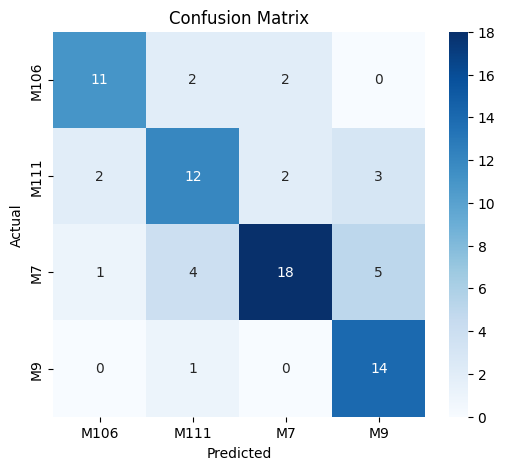

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

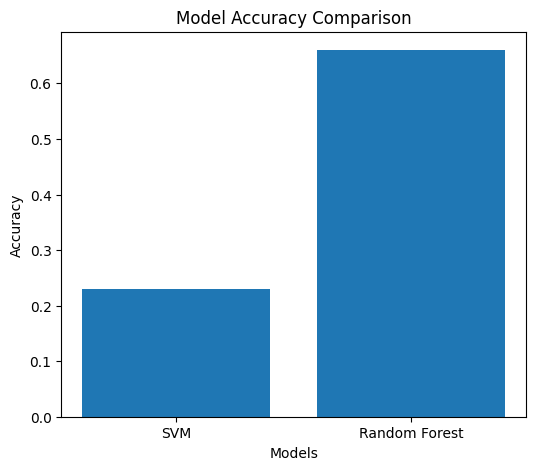

In [ ]:
import matplotlib.pyplot as plt

models = ['SVM', 'Random Forest']
accuracies = [0.23, 0.66]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

       Feature  Importance
0     Contrast    0.122763
1  Correlation    0.119267
2       Energy    0.147913
3  Homogeneity    0.221845
4     LBP_Mean    0.214304
5      LBP_STD    0.173908


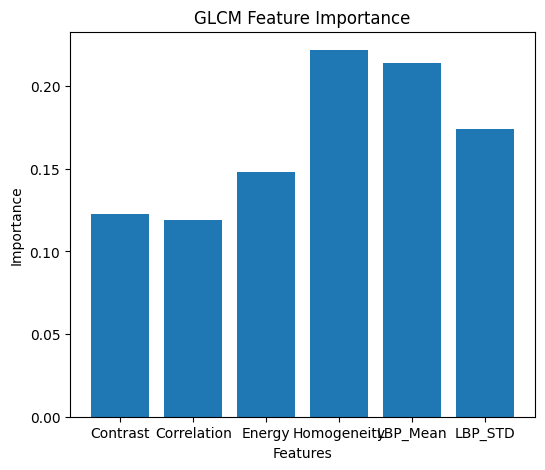

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_names = ['Contrast',
                 'Correlation',
                 'Energy',
                 'Homogeneity',
                 'LBP_Mean',
                 'LBP_STD'
                 ]

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

print(feature_df)

plt.figure(figsize=(6,5))

plt.bar(feature_names, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("GLCM Feature Importance")

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['SVM', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy]
})

print(results)

           Model  Accuracy
0            SVM  0.233766
1  Random Forest  0.714286


In [ ]:
results.to_csv("model_results.csv", index=False)

print("Results saved successfully")

Results saved successfully


In [ ]:
!pip install scikit-image

In [ ]:
import cv2
import os
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

dataset_path = "/content/drive/MyDrive/denoised/train"

features = []

classes = os.listdir(dataset_path)

for cls in classes:

    input_folder = os.path.join(dataset_path, cls)

    for filename in os.listdir(input_folder):

        img_path = os.path.join(input_folder, filename)

        img = cv2.imread(img_path, 0)

        # ---------------- GLCM ---------------- #

        glcm = graycomatrix(
            img,
            distances=[1],
            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm, 'contrast').mean()

        correlation = graycoprops(glcm, 'correlation').mean()

        energy = graycoprops(glcm, 'energy').mean()

        homogeneity = graycoprops(glcm, 'homogeneity').mean()

        # ---------------- LBP ---------------- #

        radius = 1

        n_points = 8 * radius

        lbp = local_binary_pattern(
            img,
            n_points,
            radius,
            method='uniform'
        )

        lbp_mean = lbp.mean()

        lbp_std = lbp.std()

        # -------- COMBINED FEATURES -------- #

        features.append([
            contrast,
            correlation,
            energy,
            homogeneity,
            lbp_mean,
            lbp_std,
            cls
        ])

# Create dataframe

df = pd.DataFrame(features, columns=[
    'Contrast',
    'Correlation',
    'Energy',
    'Homogeneity',
    'LBP_Mean',
    'LBP_STD',
    'Label'
])

print(df.head())

    Contrast  Correlation    Energy  Homogeneity  LBP_Mean   LBP_STD Label
0  66.279387     0.954386  0.024927     0.199219  4.460997  1.874637    M7
1  64.719225     0.955474  0.024721     0.200186  4.455317  1.865974    M7
2  59.194677     0.951566  0.025165     0.205250  4.465900  1.841060    M7
3  60.510328     0.951262  0.025001     0.204631  4.456533  1.848361    M7
4  65.836841     0.963952  0.024730     0.195244  4.463528  1.890736    M7


In [ ]:
import joblib

joblib.dump(rf_model, 'random_forest_model.pkl')

print("Model saved successfully")

Model saved successfully


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
train_dir = "/content/drive/MyDrive/dataset/train"
test_dir = "/content/drive/MyDrive/dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [ ]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 175s 7s/step - accuracy: 0.2865 - loss: 2.8375 - val_accuracy: 0.4792 - val_loss: 1.2842
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 151s 6s/step - accuracy: 0.5286 - loss: 1.0901 - val_accuracy: 0.4688 - val_loss: 1.4799
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step - accuracy: 0.6250 - loss: 0.8708 - val_accuracy: 0.5938 - val_loss: 0.9435
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 154s 6s/step - accuracy: 0.7318 - loss: 0.7050 - val_accuracy: 0.5729 - val_loss: 0.9561
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 156s 7s/step - accuracy: 0.7812 - loss: 0.5637 - val_accuracy: 0.5625 - val_loss: 0.9385
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 0.8359 - loss: 0.4669 - val_accuracy: 0.6146 - val_loss: 0.9018
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 146s 6s/step - accuracy: 0.8490 - loss: 0.3804 - val_accuracy: 0.7083 - val_loss: 0.7568
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.9479 - loss: 0.1891 - val_accuracy: 0.7188 - v

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

In [ ]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 163s 7s/step - accuracy: 0.5938 - loss: 1.0885 - val_accuracy: 0.6146 - val_loss: 0.8258
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - accuracy: 0.8099 - loss: 0.5318 - val_accuracy: 0.7917 - val_loss: 0.6003
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 136s 6s/step - accuracy: 0.8516 - loss: 0.3760 - val_accuracy: 0.8021 - val_loss: 0.5145
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.9062 - loss: 0.2731 - val_accuracy: 0.7292 - val_loss: 0.6077
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.9323 - loss: 0.2126 - val_accuracy: 0.8854 - val_loss: 0.3594
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 144s 5s/step - accuracy: 0.9531 - loss: 0.1959 - val_accuracy: 0.8333 - val_loss: 0.3830
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - accuracy: 0.9375 - loss: 0.1765 - val_accuracy: 0.8750 - val_loss: 0.3256
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.9792 - loss: 0.1177 - val_accuracy: 0.8333 - v

In [ ]:
model.save("mobilenet_rootstock_model.h5")

print("Model saved successfully")

Model saved successfully


In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Final Accuracy:", accuracy*100)

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8646 - loss: 0.3076
Final Accuracy: 86.45833134651184


In [ ]:
import numpy as np

pred = model.predict(test_generator)

predicted_classes = np.argmax(pred, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 71s 13s/step


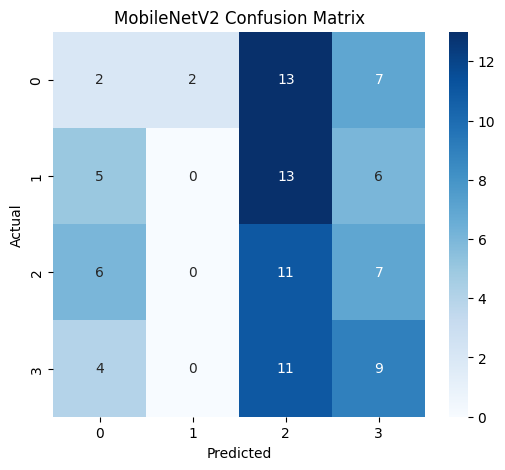

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_generator.classes,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_generator.classes,
    predicted_classes,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

        M106       0.23      0.29      0.26        24
        M111       0.27      0.29      0.28        24
          M7       0.24      0.17      0.20        24
          M9       0.30      0.29      0.30        24

    accuracy                           0.26        96
   macro avg       0.26      0.26      0.26        96
weighted avg       0.26      0.26      0.26        96



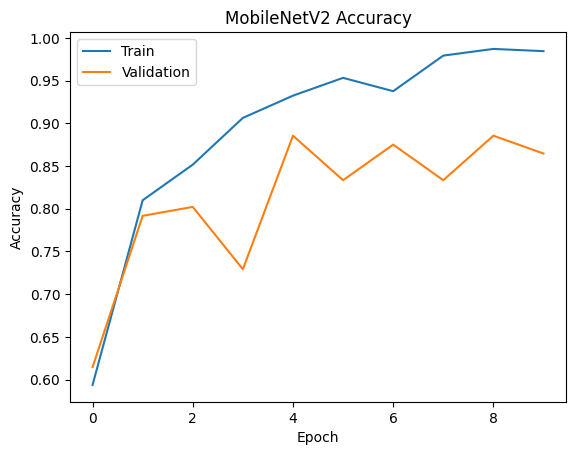

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

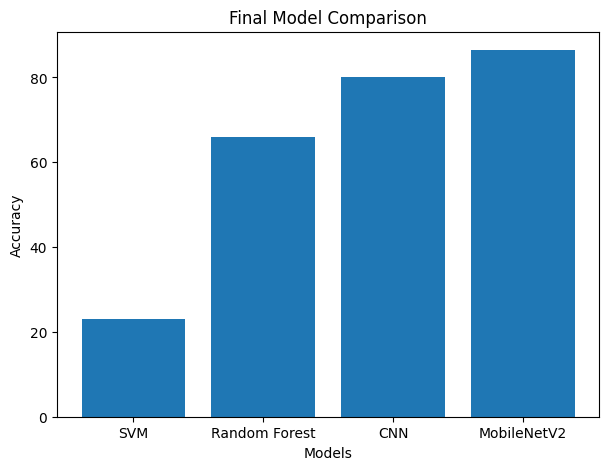

In [ ]:
models = ['SVM', 'Random Forest', 'CNN', 'MobileNetV2']

accuracies = [23, 66, 80, 86.45]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Final Model Comparison")

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'CNN', 'MobileNetV2'],
    'Accuracy': [23, 66, 80, 86.45]
})

print(results)

           Model  Accuracy
0            SVM     23.00
1  Random Forest     66.00
2            CNN     80.00
3    MobileNetV2     86.45


In [ ]:
plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Final Model Comparison")

plt.show()

In [ ]:
results.to_csv("final_results.csv", index=False)

print("Results saved successfully")

Results saved successfully


In [ ]:
model.save("apple_rootstock_model.h5")

print("Model saved successfully")

Model saved successfully


In [ ]:
!pip install streamlit pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 26.1 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!cat /content/logs.txt



2026-05-26 08:54:22.373 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.186.150.191:8501



In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3EFftw43x8yESr4eBFp8ToMLpDh_3j6LbvB1HVM9g7gFpefvL")

In [ ]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://acrobat-arose-suave.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

model = load_model("mobilenet_rootstock_model.h5")

classes = ['M106', 'M111', 'M7', 'M9']

st.title("🍎 Apple Rootstock Classification")

uploaded_file = st.file_uploader("Choose an image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded Image", use_column_width=True)

    img = img.resize((224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    st.success(f"Prediction: {predicted_class}")
    st.info(f"Confidence: {confidence:.2f}%")

Writing app.py


In [ ]:
!ls

apple_rootstock_model.h5  final_results.csv		sample_data
app.py			  logs.txt
drive			  mobilenet_rootstock_model.h5


In [ ]:
!streamlit run app.py &



2026-05-26 07:46:11.289 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.186.150.191:8501

2026-05-26 07:48:23.420362: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-05-26 07:48:48.925 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `width` parameter instead.
────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/exec_code.py:  
  129 in exec_func_with_error_handling                                                  
                                                                                        
  /usr/local/lib/python3.12/dist-packages/streamlit/runti

  Stopping...
